# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [29]:
import pandas as pd
import numpy as np
!pip install biopython
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df_genes = pd.read_csv("/content/genes.csv", index_col="Unnamed: 0")
df_genes.head()

,n_caracteres,inicio_genes,num_de_a,hu_no_nome
adeI,4,ad,1,False
oxa-23,6,ox,1,False
arr,3,ar,1,False
sul,3,su,0,False
adeN,4,ad,1,False


In [35]:
df_genes['id_protein'] = [
    "WP_001046004.1",
    "WP_063860633.1",
    "WP_013263789.1",
    "WP_004201164.1",
    "WP_063856115.1",
]

df_genes['id_entrez'] = [
    "NG_049525.1",
    "NG_049243.1",
    "NG_050336.1",
    "NG_049326.1",
    "NG_048222.1",
]

df_genes

,n_caracteres,inicio_genes,num_de_a,hu_no_nome,id_entrez,id_protein
adeI,4,ad,1,False,NG_049525.1,WP_001046004.1
oxa-23,6,ox,1,False,NG_049243.1,WP_063860633.1
arr,3,ar,1,False,NG_050336.1,WP_013263789.1
sul,3,su,0,False,NG_049326.1,WP_004201164.1
adeN,4,ad,1,False,NG_048222.1,WP_063856115.1


In [41]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "isabeldefariasribeiro@gmail.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"/content/Resultado/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)

    return None

In [42]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)
    print(nome_gene, id_gene)

adeI WP_001046004.1
oxa-23 WP_063860633.1
arr WP_013263789.1
sul WP_004201164.1
adeN WP_063856115.1


In [43]:
descr_gene = {}
for gene in df_genes.index:
    caminho = f"/content/Resultado/{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
descr_gene_df = pd.DataFrame.from_dict(descr_gene, orient='index')
descr_gene_df.head()

,gene,cod,seq
adeI,adeI,>WP_001046004.1,MNKYFTCYVVASLFLSGCTVQHNLINETPSQIVQGHNQVIHQYFDE...
oxa-23,oxa-23,>WP_063860633.1,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...
arr,arr,>WP_013263789.1,MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRL...
sul,sul,>WP_004201164.1,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...
adeN,adeN,>WP_063856115.1,MKIINIGVLAHVDAGKTTLTESLLYNSGAITELGSVDKGTTRTDNT...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [49]:
protein_seq = {
    df_genes.index[0]: 'MNKYFTCYVVASLFLSGCTVQHNLINETPSQIVQGHNQVIHQYFDEKNTSGVLVIQTDKKINLYGNALSRANTEYVPASTFKMLNALIGLENQKTDINEIFKWKGEKRSFTAWEKDMTLGEAMKLSAVPVYQELARRIGLDLMQKEVKRIGFGNAEIGQQVDNFWLVGPLKVTPIQEVEFVSQLAHTQLPFSEKVQANVKNMLLLEESNGYKIFGKTGWAMDIKPQVGWLTGWVEQPDGKIVAFALNMEMRSEMPASIRNELLMKSLKQLNII',
    df_genes.index[1]: 'MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGVYAMDTGSGATVSYRAEERFPLCSSFKGFLAAAVLARSQQQAGLLDTPIRYGKNALVRWSPISEKYLTTGMTVAELSAAAVQYSDNAAANLLLKELGGPAGLTAFMRSIGDTTFRLDRWELELNSAIPGDARDTSSPRAVTESLQKLTLGSALAAPQRQQFVDWKGNTTGNHRIRAAVPADWAVGDKTGTCGVYGTANDYAVVWPTGRAPIVLAVYTRAPNKDDKYSEAVIAAAARLALEGLGVNGQ',
    df_genes.index[2]: 'MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRLYQIADGVWSHIATQSFDGAVYPSNGLIVRDGDELLLIDTAWGAKNTAALLAEIEKQIGLPVTRAVSTHFHDDRVGGVDVLRAAGVATYASPSTRRLAEAEGNEIPTHSLEGLSSSGDAVRFGPVELFYPGAAHSTDNLVVYVPSANVLYGGCAVHELSSTSAGNVADADLAEWPTSVERIQKHYPEAEVVIPGHGLPGGLDLLQHTANVVKAHKNRSVAE',
    df_genes.index[3]: 'MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRFGDLVFRQLAPNVWQHTSYLDMPGFGAVASNGLIVRDGGRVLVVDTAWTDDQTAQILNWIKQEINLPVALAVVTHAHQDKMGGMDALHAAGIATYANALSNQLAPQEGMVAAQHSLTFAANGWVEPATAPNFGPLKVFYPGPGHTSDNITVGIDGTDIAFGGCLIKDSKAKSLGNLGDADTEHYAASARAFGAAFPKASMIVMSHSAPDSRAAITHTARMADKLR',
    df_genes.index[4]: 'MKIINIGVLAHVDAGKTTLTESLLYNSGAITELGSVDKGTTRTDNTLLERQRGITIQTGITSFQWENTKVNIIDTPGHMDFLAEVYRSLSVLDGAILLISAKDGVQAQTRILFHALRKMGIPTIFFINKIDQNGIDLSTVYQDIKEKLSAEIVIKQKVELYPNMCVTNFTESEQWDTVIEGNDDLLEKYTSGKLLEALELEQEESIRFHNCSLFPVYHGSAKNNIGIDNLIEVITNKFYSSTHRGQSELCGKVFKIEYTKKRQRLAYIRLYSGVLHLRDSVRVSEKEKIKVTEMYTSINGELCKIDRAYSGEIVILQNEFLKLNSVLGDTKLLPQRKKIENPHPLLQTTVEPSKPEQREMLLDALLEISDSDPLLRYYVDSTTHEIILSFLGKVQMEVISALLQEKYHVEIELKEPTVIYMERPLKNAEYTIHIEVPPNPFWASIGLSVSPLPLGSGMQYESSVSLGYLNQSFQNAVMEGIRYGCEQGLYGWNVTDCKICFKYGLYYSPVSTPADFRMLAPIVLEQVLKKAGTELLEPYLSFKIYAPQEYLSRAYNDAPKYCANIVDTQLKNNEVILSGEIPARCIQEYRSDLTFFTNGRSVCLTELKGYHVTTGEPVCQPRRPNSRIDKVRYMFNKIT',
}


df_seq = pd.DataFrame.from_dict(protein_seq, orient='index',columns=['seq'])

from collections import Counter

freq_dict = {}

for gene, seq in protein_seq.items():
    freq_dict[gene] = Counter(seq)

df_freq = pd.DataFrame.from_dict(freq_dict, orient='index').fillna(0).astype(int)
df_freq

,M,N,K,Y,F,T,C,V,A,S,L,G,Q,H,I,E,P,D,R,W
adeI,11,19,22,7,12,14,2,21,16,14,27,18,18,4,18,20,9,8,7,6
oxa-23,4,10,10,10,9,21,3,19,44,21,33,26,10,1,8,12,13,14,18,6
arr,3,9,6,9,4,14,1,30,32,23,25,24,5,11,11,18,15,13,10,3
sul,12,11,9,4,9,17,2,16,41,14,22,25,12,10,14,7,15,17,9,4
adeN,12,31,42,32,20,42,11,41,26,45,70,37,27,12,53,52,27,27,28,4


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [53]:
valinas = df_freq['V']
valinas_2 = valinas.idxmax()
print(valinas)
print(f"O gene com maior número de valinas é {valinas_2}")

adeI      21
oxa-23    19
arr       30
sul       16
adeN      41
Name: V, dtype: int64
O gene com maior número de valinas é adeN


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [58]:
media_s = df_freq['S'].mean()
moda_s = df_freq['S'].mode()
mediana_s = df_freq['S'].median()
print(f"Média: {media_s}")
print(f"Moda: {moda_s}")
print(f"Mediana: {mediana_s}")

Média: 23.4
Moda: 0    14
Name: S, dtype: int64
Mediana: 21.0


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

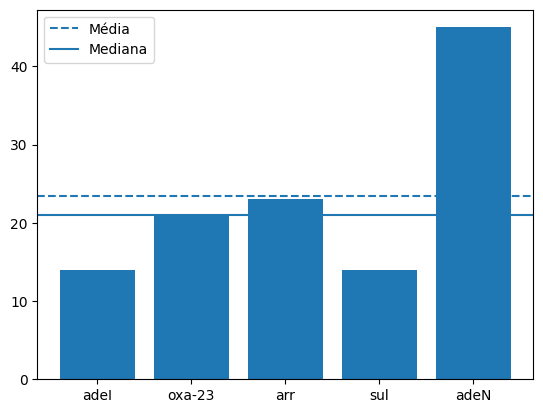

In [62]:
import matplotlib.pyplot as plt

plt.bar(df_freq.index, df_freq['S'])
plt.axhline(df_freq['S'].mean(), linestyle='--', label='Média')
plt.axhline(df_freq['S'].median(), linestyle='-', label='Mediana')
plt.legend()
plt.show()


## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_aa_por_gene(df, aa, ordenar=True):
    aa = aa.upper()

    if aa not in df.columns:
        raise ValueError(f"{aa} não está nas colunas do DataFrame.")
    serie = df[aa]
    if not pd.api.types.is_numeric_dtype(serie):
        raise TypeError(f"{aa} precisa ser numérico.")

    if ordenar:
        serie = serie.sort_values()

    media = serie.mean()
    mediana = serie.median()

    fig, ax = plt.subplots()

    ax.bar(serie.index, serie.values)

    ax.axhline(media, linestyle="--", label=f"Média: {media:.2f}")
    ax.axhline(mediana, linestyle="-", label=f"Mediana: {mediana:.2f}")

    ax.legend()

    plt.tight_layout()
    plt.show()

    return media, mediana



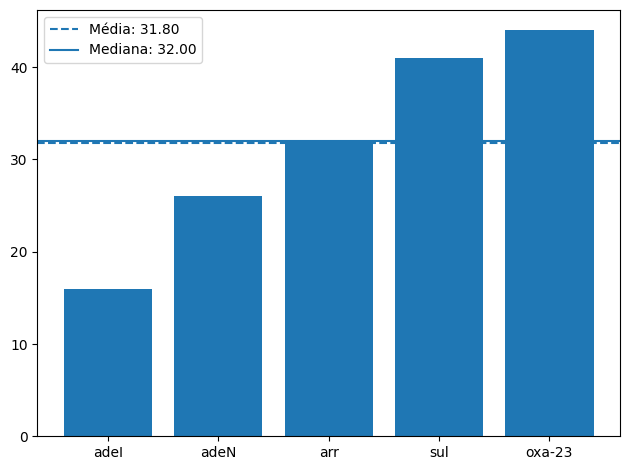

(np.float64(31.8), 32.0)

In [73]:
plot_aa_por_gene(df_freq, 'a')

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

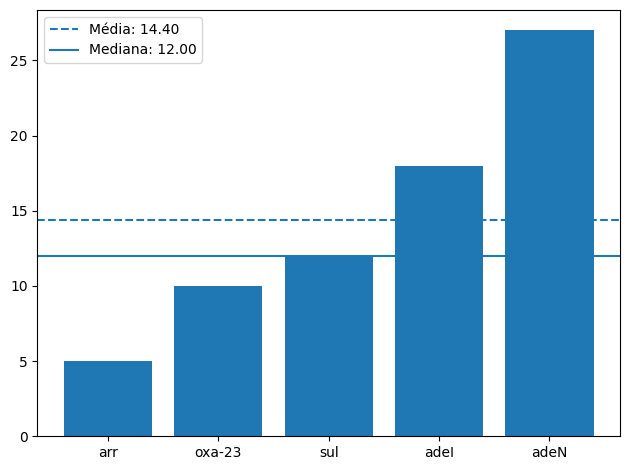

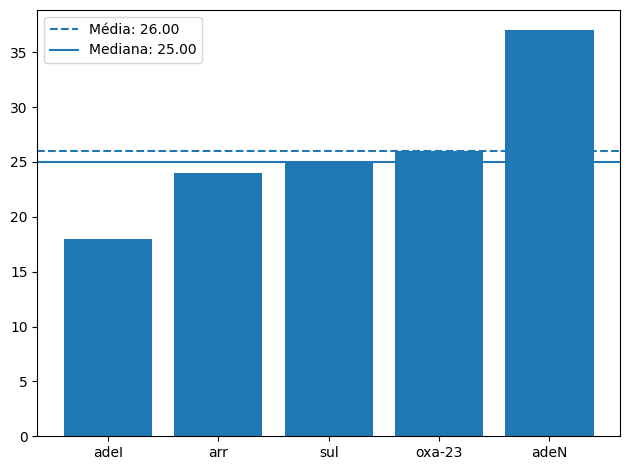

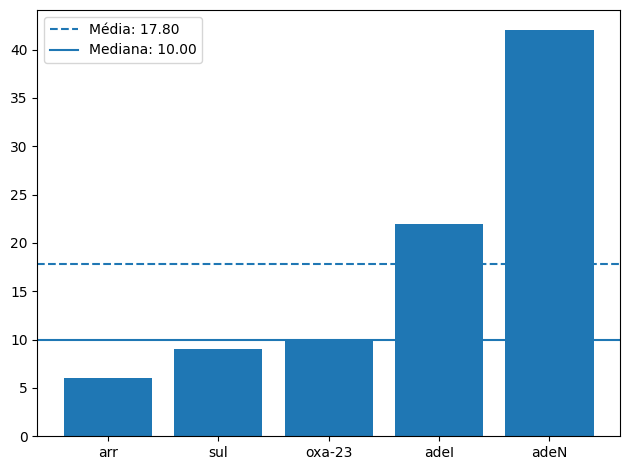

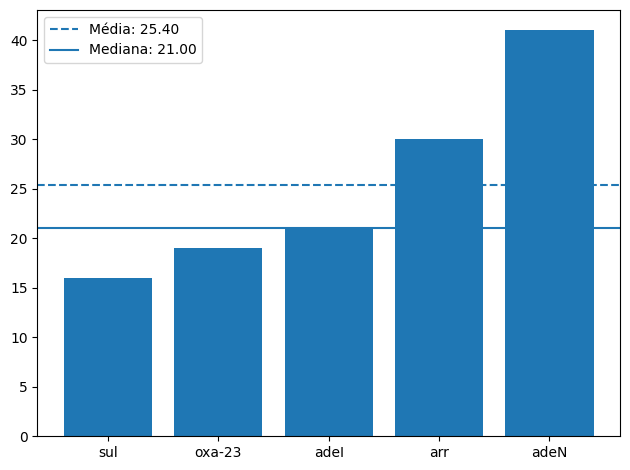

(np.float64(25.4), 21.0)

In [74]:
plot_aa_por_gene(df_freq, 'Q')
plot_aa_por_gene(df_freq, 'G')
plot_aa_por_gene(df_freq, 'K')
plot_aa_por_gene(df_freq, 'V')

A Glicina possui a menor diferença entre média e mediana.

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [82]:
cisteina = df_freq.loc[df_genes.index[:3], 'C']
media_c = cisteina.mean()
mediana_c = cisteina.median()
print(f"Média de cisteina: {media_c}")
print(f"Mediana de cisteina: {mediana_c}")

Média de cisteina: 2.0
Mediana de cisteina: 2.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [85]:
df_freq['media_aa'] = df_freq.mean(axis=1)
# gene com maior média
maior_gene = df_freq["media_aa"].idxmax()
valor = df_freq["media_aa"].max()

print(f"Maior gene: {maior_gene} (média = {valor:.2f})")

Maior gene: adeN (média = 31.95)


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [86]:
menor_gene = df_freq["media_aa"].idxmin()
valor = df_freq["media_aa"].min()

print(f"Menor gene: {menor_gene} (média = {valor:.2f})")

Menor gene: arr (média = 13.30)
